# Bài tập cá nhân môn Trí tuệ nhận tạo UTH 2026

---

## Mục tiêu bài tập

- __Mô tả:__ Sử dụng Linear Regression để dự đoán giá của các căn nhà dựa trên các yếu tố như diện tích, số phòng, vị trí, v.v.

- __Dữ liệu:__ Tập dữ liệu có thể được thu thập từ các trang web bất động sản, từ cơ quan quản lý bất động sản hoặc từ các dịch vụ môi giới bất động sản. Dữ liệu này bao gồm các thông tin về các căn nhà như diện tích, số phòng, vị trí, tiện ích xung quanh và giá bán thực tế.

- __Yêu cầu:__

    1. __Tiền xử lý dữ liệu:__ Đọc và khám phá dữ liệu. Xử lý dữ liệu thiếu, loại bỏ nhiễu, chuẩn hóa dữ liệu nếu cần. Chọn các đặc trưng phù hợp cho mô hình Linear Regression.

    2. __Chia tập dữ liệu:__ Chia dữ liệu thành tập huấn luyện và tập kiểm tra.

    3. __Xây dựng mô hình Linear Regression:__ Sử dụng tập dữ liệu huấn luyện để xây dựng một mô hình Linear Regression.

    4. __Đánh giá mô hình:__ Sử dụng tập dữ liệu kiểm tra để đánh giá hiệu suất của mô hình Linear Regression trong việc dự đoán giá nhà.

    5. __Tinh chỉnh mô hình:__ Thử nghiệm với các tham số khác nhau của Linear Regression như hệ số điều chỉnh (alpha), số lượng đặc trưng, v.v. để cải thiện hiệu suất của mô hình.

    6. __Dự đoán:__ Sử dụng mô hình tốt nhất để dự đoán giá nhà cho các căn nhà mới.

---

## Pipeline Tổng quát áp dụng cho bài tập
1. Data collection & Understanding
2. Data Preprocessing
3. Data Splitting (Train / Validation / Test)
4. Model Selection & Training
5. Evaluation & Tuning
6. Deployment & Monitoring (Predict cho dữ liệu mới.)

---

## Machine Learning Pipeline
```mermaid
flowchart LR

    A([Dataset]) --> B["1. Data Collection<br/>& Understanding"]

    B --> C["2. Data Preprocessing"]

    C --> D["3. Data Splitting<br/>(Train / Validation / Test)"]

    D --> E["4. Model Selection<br/>& Training"]

    E --> F["5. Evaluation<br/>& Hyperparameter Tuning"]

    F -->|Performance đạt yêu cầu| G["6. Deployment & Monitoring"]

    G --> H([Predict New Data])

    F -->|Performance chưa đạt| C
```

---

## Các thuật toán sử dụng trong bài tập

1. __IQR (Interquartile Range) - Xử lý Outlier__

- Áp dụng cho các cột dữ liệu **Numerical**.
- Sử dụng khoảng tứ phân vị (Interquartile Range - IQR) để phát hiện các giá trị ngoại lai.
- Công thức:

  - __Q1: Phân vị 25%__
  - __Q3: Phân vị 75%__
  - __IQR = Q3 − Q1__

- Một giá trị được xem là Outlier nếu:

  - Giá trị < Q1 − 1.5 × IQR
  - Giá trị > Q3 + 1.5 × IQR

- Trong bài tập, các Outlier được loại bỏ nhằm giảm ảnh hưởng của các giá trị bất thường đến mô hình Linear Regression.

2. __Median Imputation - Xử lý Missing Values__

- Áp dụng cho các cột dữ liệu **Numerical** có giá trị bị thiếu.
- Giá trị thiếu được thay thế bằng **Median** của từng nhóm `Regionname`.
- Nếu một nhóm không đủ dữ liệu để tính Median, sẽ sử dụng Median của toàn bộ tập dữ liệu.

**Lý do lựa chọn Median:**

- Ít bị ảnh hưởng bởi Outlier hơn Mean.
- Phù hợp với các biến có phân phối lệch như:
  - BuildingArea
  - YearBuilt
  - Landsize

3. __One-Hot Encoding - Mã hóa dữ liệu Categorical__

- Áp dụng cho các cột dữ liệu **Categorical** như:
  - Suburb
  - Type
  - Method
  - Regionname
  - CouncilArea
  - SellerG
  - ...

- One-Hot Encoding chuyển mỗi giá trị phân loại thành một cột nhị phân (0 hoặc 1).

4. __StandardScaler - Chuẩn hóa dữ liệu__

- Áp dụng cho các cột dữ liệu **Numerical** sau khi xử lý Missing Values và Outlier.

- Công thức:

$$
z=\frac{x-\mu}{\sigma}
$$

Trong đó:

- $x$: giá trị gốc
- $\mu$: giá trị trung bình
- $\sigma$: độ lệch chuẩn

Sau khi chuẩn hóa:

- Mean ≈ 0
- Standard Deviation ≈ 1

**Lý do sử dụng StandardScaler:**

- Đưa các đặc trưng về cùng một thang đo.
- Giảm ảnh hưởng của sự khác biệt về đơn vị đo giữa các biến.
- Giúp quá trình huấn luyện mô hình Linear Regression ổn định và dễ hội tụ hơn.

5. Frequency Encoding (Mã hóa theo tần suất)
- Nhãn nào xuất hiện càng nhiều trong dữ liệu thì giá trị số của nó càng lớn. Phương pháp này thay thế tên nhãn chữ bằng tần suất xuất hiện (số lần đếm hoặc tỷ lệ %) của chính nhãn đó trong tập dữ liệu.

- Ưu điểm: Đơn giản mang tốc độ tính toán nhanh, không lo bị Data Leakage từ biến mục tiêu
- Nhược điểm: Mô hình bị 'Lú' nếu có 2 vùng khác nhau nhưng lại có cùng tấn suất.

6. Target Encoding / Mean Encoding (Mã hóa theo biến mục tiêu)
- Phương pháp này cực kỳ thông minh và có tính "kinh tế" cao. Nó thay thế tên nhãn chữ bằng giá trị trung bình của biến mục tiêu (Price) của riêng nhãn đó.

- Ưu điểm mang lại hiệu xuất cao cho các mô hình họ nhà cây.
- Nhược điểm dễ bị Overfitting / Data Leakage

---

## Kết quả cuối cùng
- Hiểu về mô hình Linear Regression
- Hiểu về Data Pipeline & Machine Learning Pipeline
- Tìm ra tham số tốt nhất để dự đoán giá bất động sản
- Phân tích đặc điểm giữa các Feature với Target là __giá nhà (Prices)__
- Trực quan hóa Các outlier, missing Value của features
- Dựa vào Correlation Matrix để Chọn các Feature quan trọng với Target và thực hiện Feature Engineering.
- Cover doan nghiệp phân tích thị trường bất động sản và xây dựng hoạnh định chiến lược.


In [147]:
# Data Loader
import pandas as pd
from datetime import datetime

# Data Preprocessing & Feature engineering
import math
import numpy as np
from src.IQR import remove_outliers_iqr
from sklearn.preprocessing import StandardScaler
from src.One_Hot_enc import one_hot_encode
from src.Frequency_enc import frequency_encode
from category_encoders import TargetEncoder

# EDA
from matplotlib import pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation & report
from src.evaluations import regression_report

## 1. Data collection & Understanding

Bộ Dữ liệu được thu thập trên [Kaggle](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) Chứa một file csv:

- **melb_data.csv**

### Bối cảnh Bộ dữ liệu.
- Thị trường bất động sản tại Melbourne đang phát triển `bùng nổ`.

### Mục tiêu
- Sử dụng thuật toán học có giám sát __Linear Regression__ để dự đoán giá bất động sản trong bộ dữ liệu

### Mô tả các biến trong bộ dữ liệu

| Biến              | Ý nghĩa                                                                       |
| ----------------- | ----------------------------------------------------------------------------- |
| **Suburb**        | Tên khu vực/quận nơi căn nhà tọa lạc.                                         |
| **Address**       | Địa chỉ cụ thể của căn nhà.                                                   |
| **Rooms**         | Số lượng phòng của bất động sản.                                              |
| **Price**         | Giá bán của bất động sản (đơn vị: đô la Úc - AUD).                            |
| **Method**        | Phương thức bán bất động sản.                                                 |
| **Type**          | Loại hình bất động sản.                                                       |
| **SellerG**       | Đại lý hoặc công ty môi giới bất động sản.                                    |
| **Date**          | Ngày giao dịch (ngày bán).                                                    |
| **Distance**      | Khoảng cách từ bất động sản đến khu trung tâm thương mại (CBD).               |
| **Regionname**    | Khu vực tổng quát của bất động sản (West, North West, North, North East,...). |
| **Propertycount** | Số lượng bất động sản hiện có trong khu vực (Suburb).                         |
| **Postcode**      | Mã bưu điện của khu vực.                                                      |
| **Bedroom2**      | Số phòng ngủ được thu thập từ một nguồn dữ liệu khác.                         |
| **Bathroom**      | Số lượng phòng tắm.                                                           |
| **Car**           | Số chỗ đậu xe hoặc gara.                                                      |
| **Landsize**      | Diện tích khu đất.                                                            |
| **Lattitude**     | Vĩ độ của vị trí căn nhà.                                                     |
| **Longtitude**    | Kinh độ của vị trí căn nhà.                                                   |
| **BuildingArea**  | Diện tích xây dựng của ngôi nhà.                                              |
| **CouncilArea**   | Hội đồng địa phương (chính quyền quản lý khu vực) nơi bất động sản tọa lạc.   |
| **YearBuilt**     | Năm xây dựng căn nhà.                                                         |

#### Những Feature quan trọng mà người dùng quan tâm nhất và ảnh hưởng đến biến Target (Prices)
- **YearBuilt**: Năm xây dựng căn nhà
- **Rooms**: Số lượng phòng của bất động
- **Car**: Số chỗ đậu xe hoặc gara.
- **Landsize**: Diện tích khu đất.
- **Suburb**: Tên khu vực/quận nơi căn nhà tọa lạc.
- **Distance**: Khoảng cách từ bất động sản đến khu trung tâm thương mại (CBD).
- **BuildingArea**: Diện tích xây dựng của ngôi nhà.


### Data Loader
> Tải dữ liệu từ file csv về Data Frame dùng thư viện pandas

In [148]:
df = pd.read_csv(r"D:\Nam 2\Trí tuệ nhân tạo\E-Learning UTH AI-EX-2026\BT cá nhân\data\melb_data.csv")

samples, features = df.shape

print(f'Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: {samples} dòng (samples) và {features} cột (features)')

Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: 13580 dòng (samples) và 21 cột (features)


In [149]:
print("5 mẫu đầu tiên trong Data Frame")
df.head()

5 mẫu đầu tiên trong Data Frame


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


### Data Validation
> Kiểm tra tính hợp lệ của dữ liệu Raw xem có đúng định dạng không, có cột nào chứa các giá trị vô lý không.

In [150]:
def validate_data(df):

    current_year = datetime.now().year

    rules = {
        "Rooms": lambda x: x.between(1, 20),
        "Price": lambda x: x > 0,
        "Distance": lambda x: x >= 0,
        "Postcode": lambda x: x.between(3000, 3999),
        "Bedroom2": lambda x: x.between(0, 20),
        "Bathroom": lambda x: x.between(0, 20),
        "Car": lambda x: x.between(0, 20),
        "Landsize": lambda x: x >= 0,
        "BuildingArea": lambda x: x >= 0,
        "YearBuilt": lambda x: x.between(1800, current_year),
        "Lattitude": lambda x: x.between(-39, -37),
        "Longtitude": lambda x: x.between(144, 146),
        "Propertycount": lambda x: x > 0,
    }

    report = []

    for col in df.columns:

        total = len(df)

        missing = df[col].isna().sum()

        if col in rules:

            valid = rules[col](df[col].dropna())

            invalid = (~valid).sum()

        else:
            invalid = 0

        valid_count = total - missing - invalid

        report.append({
            "Column": col,
            "Missing": missing,
            "Invalid": invalid,
            "Valid": valid_count,
            "Valid (%)": round(valid_count / total * 100, 2)
        })

    return pd.DataFrame(report)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='mixed')

validation_report = validate_data(df)

validation_report.style.background_gradient(
    subset=["Valid (%)"],
    cmap="RdYlGn"
)

,Column,Missing,Invalid,Valid,Valid (%)
0,Suburb,0,0,13580,100.000000
1,Address,0,0,13580,100.000000
2,Rooms,0,0,13580,100.000000
3,Type,0,0,13580,100.000000
4,Price,0,0,13580,100.000000
5,Method,0,0,13580,100.000000
6,SellerG,0,0,13580,100.000000
7,Date,0,0,13580,100.000000
8,Distance,0,0,13580,100.000000
9,Postcode,0,0,13580,100.000000


### Phân tích dữ liệu
> Thống kê đơn giản Raw data ban đầu chưa qua xử lý.

In [151]:
print("Thông tin Data Frame")
df.info()

Thông tin Data Frame
<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Suburb         13580 non-null  str           
 1   Address        13580 non-null  str           
 2   Rooms          13580 non-null  int64         
 3   Type           13580 non-null  str           
 4   Price          13580 non-null  float64       
 5   Method         13580 non-null  str           
 6   SellerG        13580 non-null  str           
 7   Date           13580 non-null  datetime64[us]
 8   Distance       13580 non-null  float64       
 9   Postcode       13580 non-null  float64       
 10  Bedroom2       13580 non-null  float64       
 11  Bathroom       13580 non-null  float64       
 12  Car            13518 non-null  float64       
 13  Landsize       13580 non-null  float64       
 14  BuildingArea   7130 non-null   float64       
 15  YearBuilt

In [152]:
print("Mô tả Data Frame")
df.describe()

Mô tả Data Frame


,Rooms,Price,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,2017-01-18 11:43:14.756995,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,2016-08-10 00:00:00,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,2017-02-25 00:00:00,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,2017-06-24 00:00:00,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,2017-12-08 00:00:00,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000
std,0.955748,6.393107e+05,NaN,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772


In [153]:
# Phân tích các giá trị null/na, duplicate và missing value

def report_Data_Quanlity(df):
    record = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Missing Count': df.isnull().sum().values,
        'Missing (%)': np.round(df.isnull().mean().values * 100, 2),
        'Duplicate Rows': df.duplicated().sum()
    })
    
    return record

report_data = report_Data_Quanlity(df)

display(report_data)

,Column,Data Type,Non-Null Count,Missing Count,Missing (%),Duplicate Rows
0,Suburb,str,13580,0,0.00,0
1,Address,str,13580,0,0.00,0
2,Rooms,int64,13580,0,0.00,0
3,Type,str,13580,0,0.00,0
4,Price,float64,13580,0,0.00,0
5,Method,str,13580,0,0.00,0
6,SellerG,str,13580,0,0.00,0
7,Date,datetime64[us],13580,0,0.00,0
8,Distance,float64,13580,0,0.00,0
9,Postcode,float64,13580,0,0.00,0


### 1.1 Data Clearning
> Xử lý các dữ liệu bị lỗi thiếu và trùng lặp.
> Xử lý Outlier (giá trị ngoại lai)
> Tập chung vào các giá trị hiện tại bị Missing sau đó đến Features quan trọng.

In [154]:
# Tạo một dữ liệu tạm thời
df_temp = df

# Xử lý dữ liệu Nan
df_temp = df_temp.dropna()

# Xử lý dữ liệu trùng lặp
df_temp = df_temp.drop_duplicates()

print(f"Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: {df_temp.shape}")

Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: (6196, 21)


> Sau khi xóa thẳng các dữ liệu bị missing (Nan/Null) và xóa trùng lặp (duplicates) thì từ số mẫu ban đầu là 13580 xuống thẳng còn 6196 hơn 50% là một tổn thất về mặt dữ liệu rất lớn và dữ liệu này được lưu ở DataFrame: `df_temp`
>
> Vì tổn thật quá lớn nên Ta phải xử lý các cột Missing Value này một cách thủ công vì các giá trị Outlier vẫn còn rất lớn theo bảng describe trước đó nên khi xử lý tiếp dữ liệu sẽ quá ít để training model. Nên ta phải xử lý các giá trị bị thiếu và giá trị ngoại lại thủ công.

In [155]:
# In các cột bị thiếu dữ liệu
missing_columns_report = report_data[report_data["Missing Count"] > 0]
print(missing_columns_report[["Column", "Data Type", "Missing Count", "Missing (%)"]])

          Column Data Type  Missing Count  Missing (%)
12           Car   float64             62         0.46
14  BuildingArea   float64           6450        47.50
15     YearBuilt   float64           5375        39.58
16   CouncilArea       str           1369        10.08


### Xử lí các cột thiếu dữ liệu Thủ công.
- Ta có 4 cột là [Car], [BuildingArea], [YearBuilt] và [CouncilArea]
    - Cột Car chỉ Missing có 0.46% $\rightarrow$ Drop luôn.
    - Cột BuildingArea Missing Tận 47.5%
    - Cột YearBuilt Missing Tận 39.58%
    - Cột CouncilArea Missing mức 10.08%

#### Xử lý cho cột Car
> Giá trị Missing $\rightarrow$ xóa thẳng vì chỉ có 0.46% để giữ độ sạch của dữ liệu.

In [156]:
df = df.dropna(subset=['Car'])

print(df.shape)

(13518, 21)


#### Xử lý cột BuildingArea
> Điền Median Vì Median ít bị ảnh hưởng bởi outlier. Có thể Điền theo Khu vực Suburb hoặc Regionname.

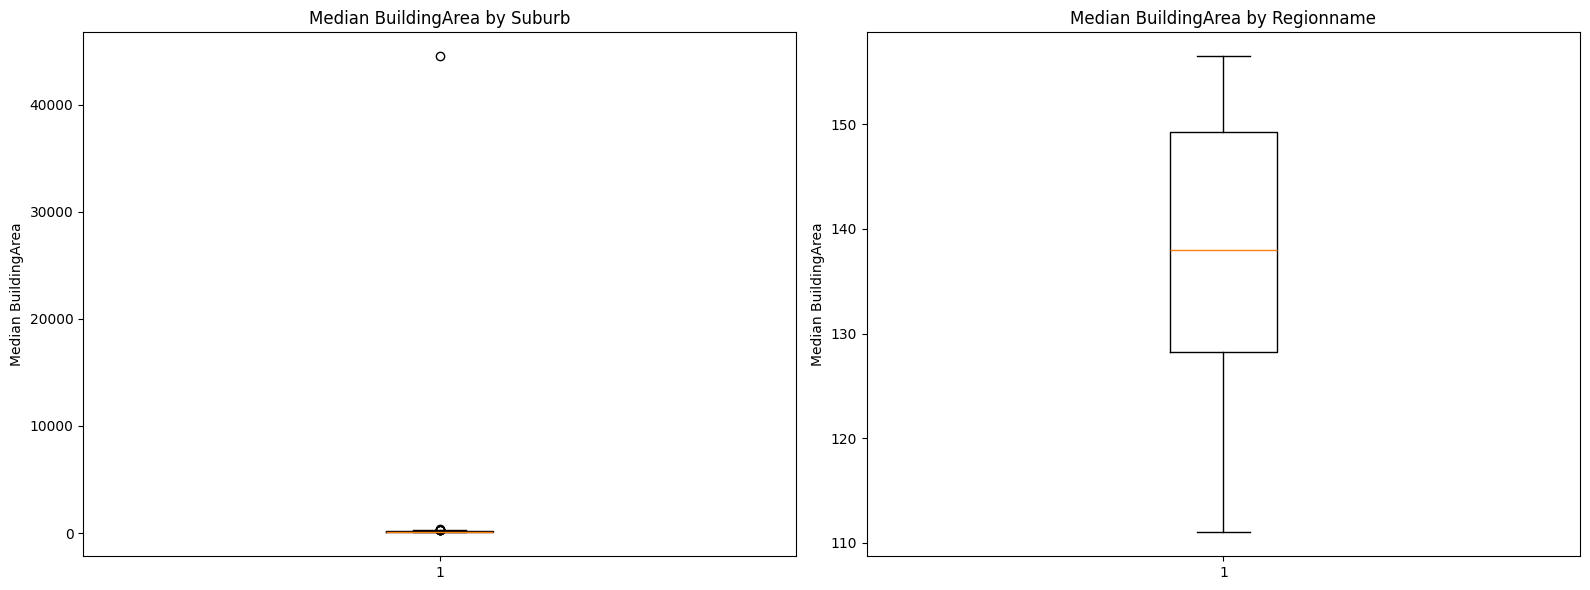

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Median theo Suburb
building_suburb = (
    df.groupby("Suburb")["BuildingArea"]
      .median()
      .dropna()
)

axes[0].boxplot(building_suburb)
axes[0].set_title("Median BuildingArea by Suburb")
axes[0].set_ylabel("Median BuildingArea")

# Median theo Regionname
building_region = (
    df.groupby("Regionname")["BuildingArea"]
      .median()
      .dropna()
)

axes[1].boxplot(building_region)
axes[1].set_title("Median BuildingArea by Regionname")
axes[1].set_ylabel("Median BuildingArea")

plt.tight_layout()
plt.show()

> Dựa vào biểu đồ ta thấy được nếu nhóm theo khu vực Regionname ta sẽ ít đụng phải outlier hơn nên ta sẽ điền fillna cho cột Suburb theo cột Regionname

In [158]:
# BuildingArea fillna theo Regionname

df["BuildingArea"] = (
    df.groupby("Regionname")["BuildingArea"]
      .transform(lambda x: x.fillna(x.median()))
)

print(df["BuildingArea"].isnull().sum())

0


#### Xử lý cột YearBuilt
> Điền Median Vì Median ít bị ảnh hưởng bởi outlier. Có thể Điền theo Khu vực Suburb hoặc Regionname.

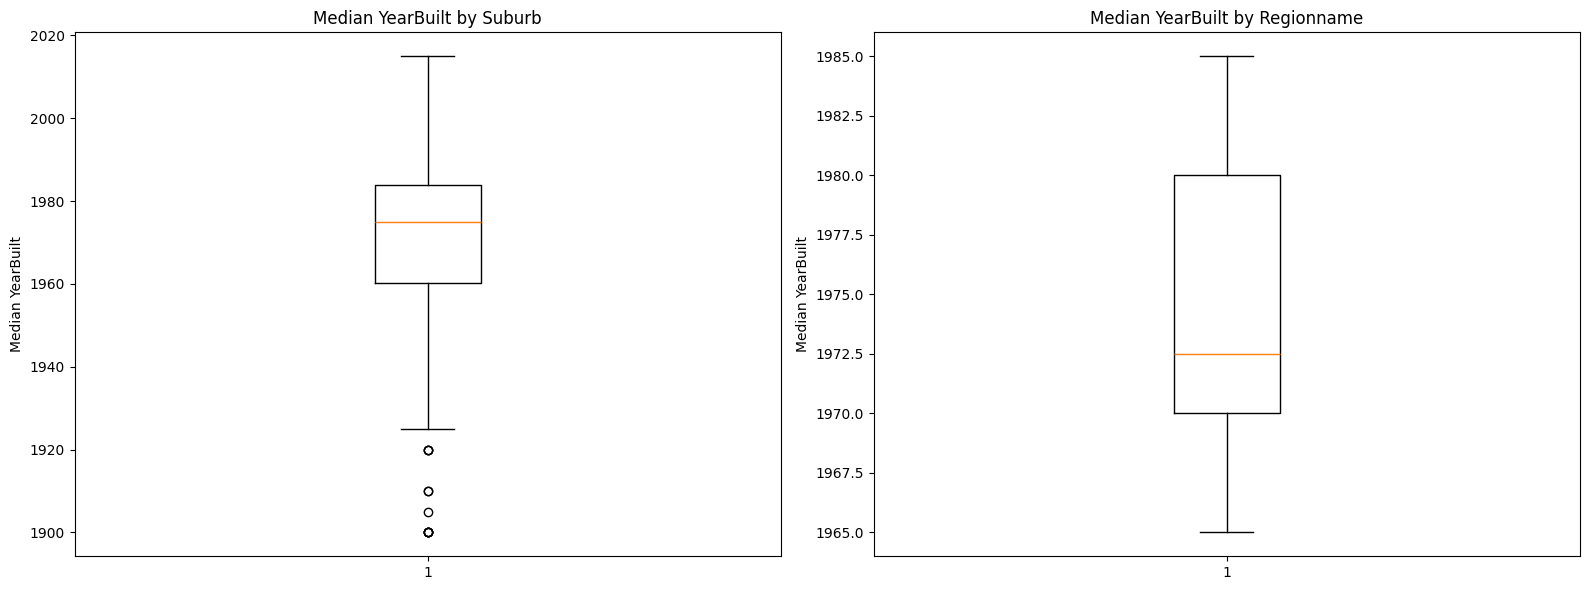

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Median theo Suburb
year_suburb = (
    df.groupby("Suburb")["YearBuilt"]
      .median()
      .dropna()
)

axes[0].boxplot(year_suburb)
axes[0].set_title("Median YearBuilt by Suburb")
axes[0].set_ylabel("Median YearBuilt")

# Median theo Regionname
year_region = (
    df.groupby("Regionname")["YearBuilt"]
      .median()
      .dropna()
)

axes[1].boxplot(year_region)
axes[1].set_title("Median YearBuilt by Regionname")
axes[1].set_ylabel("Median YearBuilt")

plt.tight_layout()
plt.show()

> Dựa vào biểu đồ ta thấy được nếu nhóm theo khu vực Regionname ta sẽ ít đụng phải outlier hơn nên ta sẽ điền fillna cho cột YearBuilt theo cột Regionname

In [160]:
# YearBuilt fillna theo Regionname

df["YearBuilt"] = (
    df.groupby("Regionname")["YearBuilt"]
      .transform(lambda x: x.fillna(x.median()))
)

print(df["YearBuilt"].isnull().sum())

0


#### Xử lý cột CouncilArea
> Điền "Unknown" vì đây là biến phân loại (categorical) để dùng One-Hot Encoding.

In [161]:
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")

print(df["CouncilArea"].isna().sum())

0


In [162]:
print("Số lượng các cột có giá trị Nan Trong Data Frame:")
print(df.isna().sum())

Số lượng các cột có giá trị Nan Trong Data Frame:
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


### Xử lý các cột Outlier

- Chỉ xử lý cho Data Type Numerical

- Trực quan hóa Outlier dùng boxplot

- Có thể xử lý theo $IQR = Q_3 - Q_1$ (Trong đó: $Q_1$: dưới 25%, $Q_3$: Trên 75%).


In [163]:
numeric_cols = ["Price", "Distance", "Bedroom2", "Bathroom", "Car",
"Landsize", "BuildingArea", "YearBuilt", "Propertycount"]

In [164]:
# Tính giá trị ở các ngưỡng (10%, 25%, 50%, 75%, 90%) Cho mỗi cột trong numeric_cols
percentiles = df[numeric_cols].quantile([0.1,0.25,0.5,0.75,0.9,0.95,0.98]).T

display(percentiles)

,0.10,0.25,0.50,0.75,0.90,0.95,0.98
Price,480000.0,650000.0,901000.0,1328000.0,1850000.0,2290150.00,2873300.00
Distance,3.5,6.2,9.2,13.0,16.2,20.60,27.00
Bedroom2,2.0,2.0,3.0,3.0,4.0,4.00,5.00
Bathroom,1.0,1.0,1.0,2.0,2.0,3.00,3.00
Car,1.0,1.0,2.0,2.0,3.0,3.00,4.00
Landsize,0.0,178.0,442.5,651.0,802.0,994.15,1772.62
BuildingArea,83.0,111.0,130.0,147.0,193.0,245.00,316.66
YearBuilt,1925.0,1960.0,1970.0,1975.0,2005.0,2011.00,2013.00
Propertycount,2671.0,4380.0,6567.0,10331.0,14042.0,14949.00,21650.00


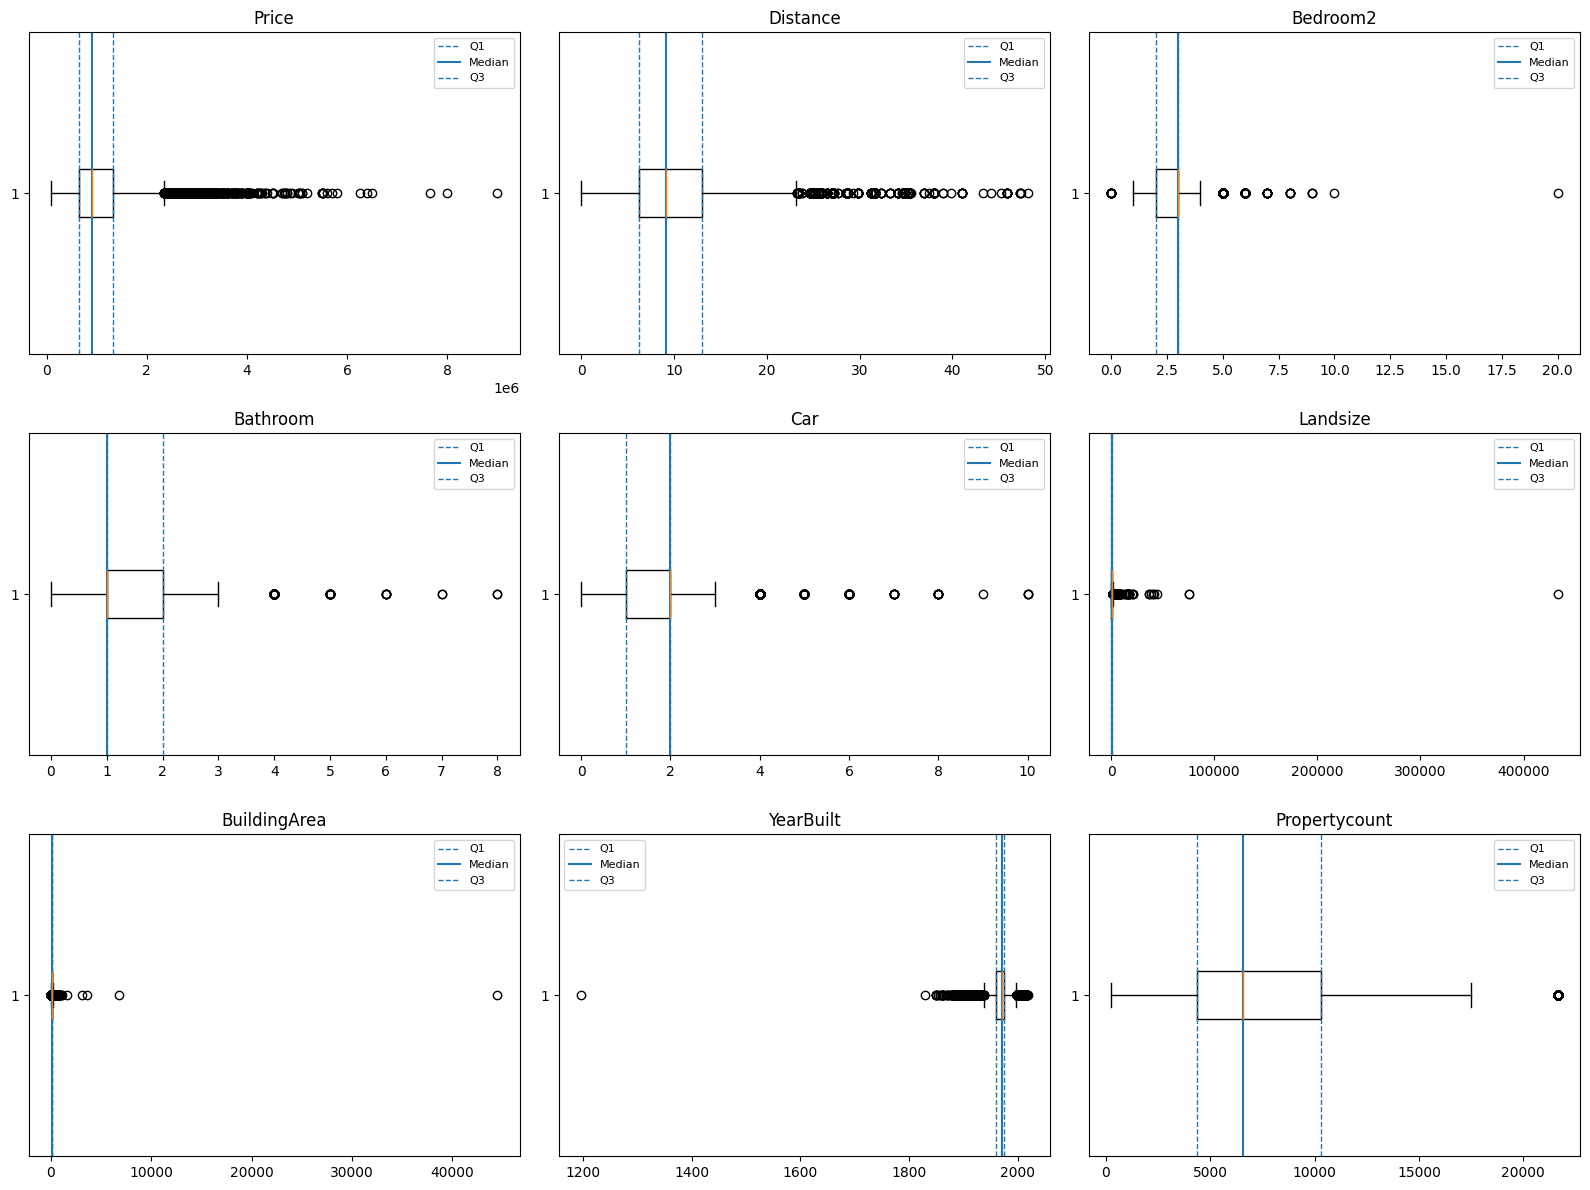

In [165]:
ncols = 3
nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    data = df[col].dropna()

    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)
    q3 = data.quantile(0.75)

    axes[i].boxplot(data, vert=False)

    axes[i].set_title(col)

    # Vẽ các đường Q1 - Median - Q3
    axes[i].axvline(q1, linestyle="--", linewidth=1, label="Q1")
    axes[i].axvline(q2, linestyle="-", linewidth=1.5, label="Median")
    axes[i].axvline(q3, linestyle="--", linewidth=1, label="Q3")

    axes[i].legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [166]:
df_Scaler = remove_outliers_iqr(df, numeric_cols)

    BÁO CÁO OUTLIERS CHO CỘT: Price
  Q1 (25th percentile)          : 650000.00
  Q3 (75th percentile)          : 1328000.00
  IQR (Interquartile Range)     : 678000.00
  Giới hạn dưới (Lower Limit)   : -367000.00
  Giới hạn trên (Upper Limit)   : 2345000.00
  Số dòng Đã xóa                : 621
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Distance
  Q1 (25th percentile)          : 6.20
  Q3 (75th percentile)          : 13.00
  IQR (Interquartile Range)     : 6.80
  Giới hạn dưới (Lower Limit)   : -4.00
  Giới hạn trên (Upper Limit)   : 23.20
  Số dòng Đã xóa                : 413
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bedroom2
  Q1 (25th percentile)          : 2.00
  Q3 (75th percentile)          : 3.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : 0.50
  Giới hạn trên (Upper Limit)   : 4.50
  Số dòng Đã xóa                : 473
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bat

> Ta thấy khi dùng IQR áp dụng hết cho các Feature nhất là Price, BuildingArea, Landsize và YearBuilt thì các giá trị Outlier lớn đã xóa phần lớn các giá trị quan trọng và tập chung dày đặc nên ta cần nới rộng các khoảng cận trên và dưới để tránh xóa các dữ liệu quan trọng.
>
> Ta có thể dựa vào biểu đồ ta phải đặt ra các mốc có thể chấp nhận được. Hoặc lựa chọn các Feature nên xóa và giữ lại những căn nhà có thể là biến động thật sự chứ không phải là nhiễu.

1. Các cột nên xử dụng hàm IQR để sử lý Outlier:
    - BuildingArea Nên nới rộng các khoảng ra để tránh xóa các dữ liệu quan trọng
    - Bathroom
    - Bedroom2
    - Car
    - Distance Có thể nới rộng IQR hơn

2. Không nên xóa hoặc xem xét biểu đồ box plot sau khi đã xử lý các cột trên trước:
    - Price Cần quan sát và chọn mức giá thủ công tránh quá lớn hoặc quá nhỏ
    - Landsize
    - Propertycount $\rightarrow$ Đây là thống kê khu vực, không nên xóa.
    - YearBuilt Nên dùng các mốc thời gian thay vì IQR

In [167]:
org_cols = ["Bedroom2", "Bathroom", "Car"]

square_cols = ["Distance", "BuildingArea"]

In [168]:
df = remove_outliers_iqr(df, org_cols)

df = remove_outliers_iqr(df, square_cols, factor=2.0)

# Chỉ lấy nhà có năm xây > năm 1800
df = df[(df['YearBuilt'] > 1800)].reset_index(drop=True)

    BÁO CÁO OUTLIERS CHO CỘT: Bedroom2
  Q1 (25th percentile)          : 2.00
  Q3 (75th percentile)          : 3.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : 0.50
  Giới hạn trên (Upper Limit)   : 4.50
  Số dòng Đã xóa                : 655
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bathroom
  Q1 (25th percentile)          : 1.00
  Q3 (75th percentile)          : 2.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : -0.50
  Giới hạn trên (Upper Limit)   : 3.50
  Số dòng Đã xóa                : 54
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Car
  Q1 (25th percentile)          : 1.00
  Q3 (75th percentile)          : 2.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : -0.50
  Giới hạn trên (Upper Limit)   : 3.50
  Số dòng Đã xóa                : 533
----------------------------------------
Tổng số dòng ban đầu : 13518
Số dòng còn lại      : 12276
Tổng số

Sau khi xử lý Oulier cho các cột features thì dữ liệu ban đầu từ 13518 đã xuống 12276 và đây là những dữ liệu ổn định hơn so với Raw ban đầu:

- Đã giải quyết các cột bị Missing Values bằng cách
    - gán giá trị Unknown cho biến phân loại
    - Gán trung vị cho các biến liên tục
    - Dùng thuật toán IQR để giải quyết Outlier cho các biến numerical.

Và thay vì Drop đi các giá trị Nan ta đã giữ lại phần data tăng tính đa dạng để mô hình học được những biến động giá và mức liên kết giữa các Feature để đưa ra dự đoán chính xác hơn.

In [169]:
df.describe()

,Rooms,Price,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,11035.000000,1.103500e+04,11035,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000
mean,2.756774,9.928470e+05,2017-01-12 14:29:05.355686,9.440770,3097.176801,2.735478,1.407612,1.418849,522.663163,123.346645,1965.790666,-37.806332,144.992011,7490.550430
min,1.000000,8.500000e+04,2016-01-28 00:00:00,0.000000,3000.000000,1.000000,0.000000,0.000000,0.000000,49.000000,1830.000000,-38.027680,144.633020,389.000000
25%,2.000000,6.350000e+05,2016-08-10 00:00:00,5.900000,3044.000000,2.000000,1.000000,1.000000,152.000000,111.000000,1960.000000,-37.854000,144.929255,4380.000000
50%,3.000000,8.700000e+05,2017-02-25 00:00:00,9.000000,3081.000000,3.000000,1.000000,1.000000,354.000000,130.000000,1970.000000,-37.800600,144.996800,6567.000000
75%,3.000000,1.250000e+06,2017-06-17 00:00:00,12.600000,3146.000000,3.000000,2.000000,2.000000,619.000000,130.000000,1970.000000,-37.756410,145.051900,10331.000000
max,6.000000,9.000000e+06,2017-12-08 00:00:00,26.500000,3754.000000,4.000000,3.000000,3.000000,433014.000000,204.000000,2017.000000,-37.568570,145.330730,21650.000000
std,0.785101,5.158326e+05,NaN,4.758758,69.091464,0.775559,0.557266,0.720507,4305.608817,28.048402,27.806878,0.070346,0.094696,4408.940649


### 1.2 EDA
> Cái nhìn trực quan nhất về mối quan hệ giữa features và Target.

In [170]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,1.0,1.0,202.0,111.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,2.0,1.0,94.0,111.0,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [171]:
# Phân tích quan hệ giữa 3 thuộc tính quan trọng Price, BuildingArea và Rooms

groupby_report = df.groupby('Rooms').agg(
    Count=('Price', 'count'),                         # Số lượng căn nhà theo từng loại phòng
    Mean_Price=('Price', 'mean'),                     # Giá trung bình
    Median_Price=('Price', 'median'),                 # Giá trung vị (tránh sai lệch do outlier)
    Mean_Area=('BuildingArea', 'mean'),               # Diện tích trung bình
    Median_Area=('BuildingArea', 'median'),           # Diện tích trung vị
    Price_per_m2=('Price', lambda x: (x / df.loc[x.index, 'BuildingArea']).mean()) # Giá TB trên mỗi m2
).reset_index()

groupby_report = groupby_report.round({
    'Mean_Price': 2, 
    'Median_Price': 2, 
    'Mean_Area': 2, 
    'Median_Area': 2, 
    'Price_per_m2': 2
})

# Sắp xếp theo số phòng tăng dần
groupby_report = groupby_report.sort_values(by='Rooms')

display(groupby_report)

,Rooms,Count,Mean_Price,Median_Price,Mean_Area,Median_Area,Price_per_m2
0,1,511,452924.17,402000.0,101.58,111.0,5124.15
1,2,3506,769291.14,685000.0,106.66,111.0,7423.66
2,3,5202,1071649.00,955000.0,129.21,130.0,8383.42
3,4,1790,1348442.76,1229500.0,144.97,140.0,9604.59
4,5,24,1543004.17,1447500.0,138.88,130.0,11232.96
5,6,2,1012500.00,1012500.0,150.50,150.5,7308.93


Phân cấp giá cả cho số lượng phòng là rất rõ ràng, căn 6 phòng có thể là thuê dịch vụ phòng lớn nên sẽ có thể là rẽ hơn những phòng cặp đôi là 4 rooms và phòng gia đình là 5 rooms.

Phương trình đường hồi quy: Price = 6319.38 * BuildingArea + 213372.34


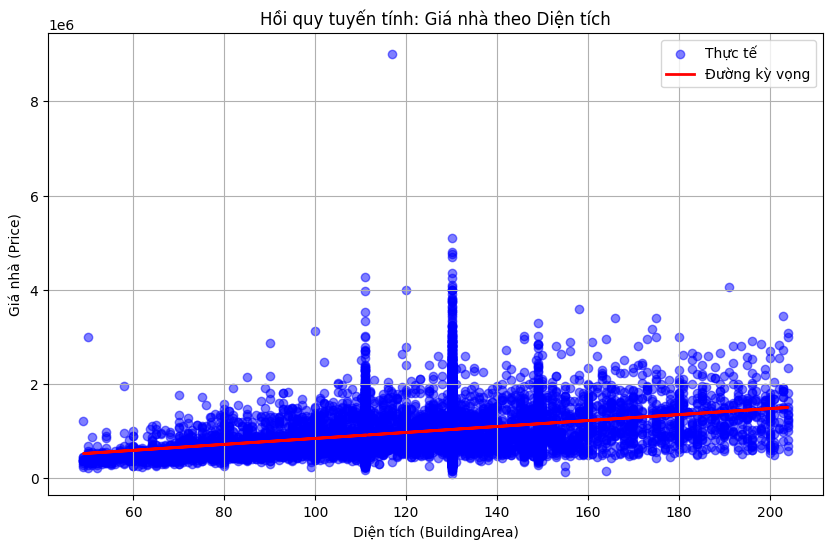

In [172]:
# EDA đơn giản và trực quan giữa giá nhà và diện tích căn nhà

# Vì cột BuildingArea của df raw ban đầu có giá trị Nan nên để minh họa ta dùng df đã drop.

X = df[["BuildingArea"]] # chuyển về mảng 2 chiều (100, 1) có 100 dòng và 1 cột rõ ràng theo quy định của sklearn
y = df["Price"]          # mảng 1 chiều (100, ) -> chỉ có chiều dọc không có chiều ngang.

# Huấn luyện mô hình để tìm đường hồi quy tuyến tính giữa Giá nhà và diện tích.
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]  # Hệ số góc Weight (w)
intercept = model.intercept_  # Hệ số chặn Bias (b)

print(f"Phương trình đường hồi quy: Price = {slope:.2f} * BuildingArea + {intercept:.2f}")

# Dự đoán giá nhà dựa trên diện tích
y_pred = model.predict(X)

# Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Scatter)
plt.scatter(df["BuildingArea"], df["Price"], color="blue", alpha=0.5, label="Thực tế")

# Vẽ đường thẳng dự đoán (Regression Line)
plt.plot(df["BuildingArea"], y_pred, color="red", linewidth=2, label="Đường kỳ vọng")

plt.title("Hồi quy tuyến tính: Giá nhà theo Diện tích")
plt.xlabel("Diện tích (BuildingArea)")
plt.ylabel("Giá nhà (Price)")
plt.legend()
plt.grid(True)
plt.show()

> Qua hình ảnh hồi quy tuyến tính Giá nhà theo Diện tích. 
>
> Sau các nổ lực xử lý giá trị Outlier và Missing Value thì ta cũng đã có một hình dáng ban đầu của việc mô hình dự đoán dữ liệu qua đường thẳng lý tưởng màu đó.
>
> Dữ liệu tập chung dày đặc ở phân khúc diện tích từ 100 $m^2$ đến 150 $m^2$ và giá trị dày đặc ở mức 2 triệu (2e6).

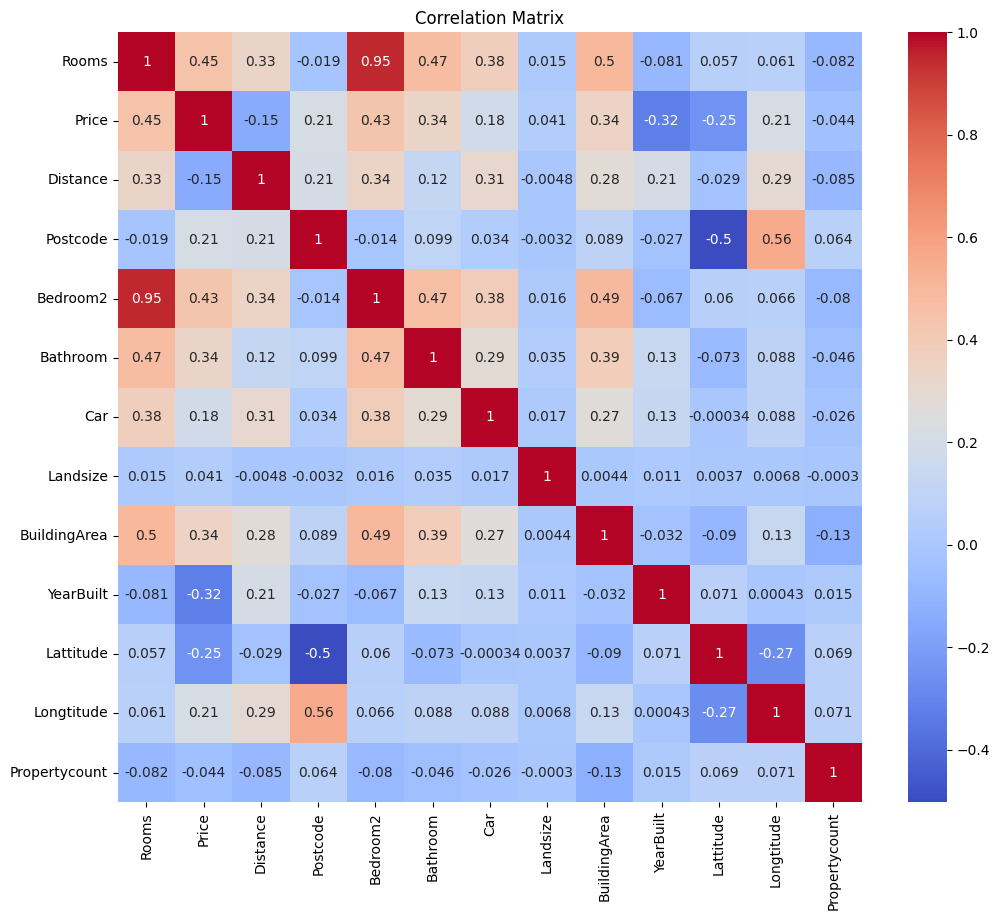

In [173]:
# Correlation Matrix để chọn các features tương quan mạnh với Target và giảm đa cộng tuyến.

plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [174]:
num_cols = df.select_dtypes(include='number')

# Tính correlation
corr = num_cols.corr(numeric_only=True)

corr_price = (
    corr["Price"]
    .sort_values(ascending=False)
)

print(corr_price)

Price            1.000000
Rooms            0.447265
Bedroom2         0.433665
BuildingArea     0.343617
Bathroom         0.335695
Postcode         0.210777
Longtitude       0.208619
Car              0.179145
Landsize         0.041065
Propertycount   -0.044427
Distance        -0.147958
Lattitude       -0.254075
YearBuilt       -0.321995
Name: Price, dtype: float64


#### Lựa chọn Features quan trọng nhất cho Model
- Tránh đa cộng tuyến và trùng lặp features không quan trọng.

> Bỏ biến Bedroom2 vì đã có Rooms mạnh hơn và tránh đa cộng tuyến giữa 2 biến
>
> Bỏ biến Address Vì mỗi địa chỉ gần như là unique và khi one-hot sẽ tọa rất nhiều cột và mô hình hầu như là học không tốt.
>
> Date thì tôi quyết định sẽ phân tích theo mùa tức là sử lý theo tháng và năm vì ngày là khoảng thời gian trải nhiều từ 1 - 31 có thể có nhiễu và thường tháng sẽ bao quát tốt hơn cũng như là để tránh mô hình học vẹt nên ta tập chung vào các tháng trong năm để phân tích mùa và quý.

## 2. Data Preprocessing
> Đưa dự liệu về dạng chuẩn để đưa vào model tránh Overfitting và Underfitting, Tránh mô hình bị 1 feature nào đó ảnh hưởng quá nhiều.
>
> Xử lý One-Hot Encoding cho Categorical
>
> Standard Scaler cho cột Numerical thay cho Min-Max Scaler để ít nhạy hơn với Outlier. Nhưng bước này ta phải làm sau khi đã chia tập train và test mới thực hiện Scaler để tránh rò rỉ dữ liệu.

### 2.1 Feature Engineering

- Cột YearBuilt $\rightarrow$ HouseAge

- Cột Date chuyển về SaleMonth và SaleYear

In [175]:
current_year = 2026 
df['HouseAge'] = current_year - df['YearBuilt']

df['SaleMonth'] = df['Date'].dt.month

df['SaleYear'] = df['Date'].dt.year

df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,HouseAge,SaleMonth,SaleYear
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,111.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,56.0,3,2016
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,126.0,4,2016
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,126.0,4,2017
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,111.0,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,56.0,4,2017
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,12.0,4,2016


In [176]:
df['SaleYear'].unique()

array([2016, 2017], dtype=int32)

Năm chỉ có 2 giá trị 2016 và 2017 nên ta có thể chuyển về dạng Binary (0 và 1).

In [177]:
df['SaleYear'] = (df['SaleYear'] == 2017).astype(int)

df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,HouseAge,SaleMonth,SaleYear
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-03-12,2.5,3067.0,...,111.0,1970.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,56.0,3,0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-04-02,2.5,3067.0,...,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,126.0,4,0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-04-03,2.5,3067.0,...,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,126.0,4,1
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-04-03,2.5,3067.0,...,111.0,1970.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,56.0,4,1
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-04-06,2.5,3067.0,...,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,12.0,4,0


### 2.2 One-Hot Encoding Categorical

- Xem xét các cột cần One-hot để xem cần tách ra bao nhiêu cột và có đáng không.
    - Suburb
    - Type
    - Method
    - SellerG
    - CouncilArea
    - Regionname

In [178]:
encoding_cols = ["Suburb", "Type", "Method", "SellerG", "CouncilArea", "Regionname"]

In [179]:
def report_onehot_columns(df, columns_to_encode, num_samples=5):
    """
    Hàm thống kê số lượng giá trị unique của các cột phân loại 
    để dự tính số lượng cột sau khi One-Hot Encoding.
    """
    print("     BÁO CÁO CÁC CỘT PHÂN LOẠI CÓ TRONG DATA FRAME (CATEGORICAL FEATURES)")
    print("")
    
    total_new_cols = 0
    
    for col in columns_to_encode:
        if col in df.columns:
            unique_values = df[col].dropna().unique()
            unique_count = df[col].nunique()
            total_new_cols += unique_count
            
            samples = list(unique_values[:num_samples])
            samples_str = ", ".join([f"'{str(s)}'" for s in samples])
            
            print(f"Cột: {col}")
            print(f"   - Số lượng nhãn duy nhất (Số cột One-Hot): {unique_count}")
            print(f"   - Mẫu {min(num_samples, unique_count)} nhãn đầu tiên: [{samples_str}]")
            
            if unique_count > num_samples:
                print(f"            (...và còn {unique_count - num_samples} nhãn khác nữa)")
        else:
            print(f"{col:<20} | Không tìm thấy cột này trong DataFrame")
            
    print("-" * 65)
    print(f"TỔNG SỐ CỘT MỚI nếu áp dụng One-Hot cho tất cả: {total_new_cols} cột.")


report_onehot_columns(df, encoding_cols)

     BÁO CÁO CÁC CỘT PHÂN LOẠI CÓ TRONG DATA FRAME (CATEGORICAL FEATURES)

Cột: Suburb
   - Số lượng nhãn duy nhất (Số cột One-Hot): 262
   - Mẫu 5 nhãn đầu tiên: ['Abbotsford', 'Airport West', 'Albert Park', 'Alphington', 'Altona']
            (...và còn 257 nhãn khác nữa)
Cột: Type
   - Số lượng nhãn duy nhất (Số cột One-Hot): 3
   - Mẫu 3 nhãn đầu tiên: ['h', 'u', 't']
Cột: Method
   - Số lượng nhãn duy nhất (Số cột One-Hot): 5
   - Mẫu 5 nhãn đầu tiên: ['S', 'SP', 'PI', 'VB', 'SA']
Cột: SellerG
   - Số lượng nhãn duy nhất (Số cột One-Hot): 226
   - Mẫu 5 nhãn đầu tiên: ['Biggin', 'Nelson', 'Jellis', 'Greg', 'LITTLE']
            (...và còn 221 nhãn khác nữa)
Cột: CouncilArea
   - Số lượng nhãn duy nhất (Số cột One-Hot): 29
   - Mẫu 5 nhãn đầu tiên: ['Yarra', 'Moonee Valley', 'Port Phillip', 'Darebin', 'Hobsons Bay']
            (...và còn 24 nhãn khác nữa)
Cột: Regionname
   - Số lượng nhãn duy nhất (Số cột One-Hot): 7
   - Mẫu 5 nhãn đầu tiên: ['Northern Metropolitan', 'Western Me

> BÙNG NỔ luôn, quá nhiều cột ta chỉ có thể áp dụng Ont-Hot Encoding cho 3 cột Type, Method và Regionname.
>
> Ta phải tìm cách chuẩn hóa riêng cho 3 cột Suburb, SellerG và CouncilArea
>
> Phải EDA một lần nữa để tìm cách sử lý chứ lớn quá rồi.

In [180]:
# Dùng One-Hot Encode để xử lý:
enc_cols = ["Type", "Method", "Regionname"]

df = one_hot_encode(df, enc_cols)

Kích thước DataFrame sau One-Hot: (11035, 36)


In [ ]:
# Frequency Encoding cho SellerG

# Kỹ thuật này giúp giữ lại thông tin về mức độ phổ biến của từng công ty môi giới 
# mà không làm tăng số chiều của dữ liệu.

df = frequency_encode(df, cols=["SellerG"])

# Hai cột CouncilArea và Suburb Ta sẻ dùng thuật toán Target Encoding 
# nhưng ta cần phải tách dữ liệu trước để tránh train học được dữ liệu của test và val.

SellerG -> thêm cột SellerG_FE


In [182]:
# Xóa các cột không quan trọng

Del_cols = ['Address', 'Date', 'SaleYear', 'YearBuilt', "SellerG"]

df = df.drop(columns=Del_cols)

df.head()

,Suburb,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,...,Method_SP,Method_VB,Regionname_Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,SellerG_FE
0,Abbotsford,2,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,111.0,...,0,0,0,0,1,0,0,0,0,343
1,Abbotsford,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,...,0,0,0,0,1,0,0,0,0,343
2,Abbotsford,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,...,1,0,0,0,1,0,0,0,0,343
3,Abbotsford,3,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,111.0,...,0,0,0,0,1,0,0,0,0,343
4,Abbotsford,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,...,0,1,0,0,1,0,0,0,0,1368


In [183]:
# Tách X (Features) và Y (Target).
y = df['Price']

X = df.drop(columns=['Price'])

print("Chỉ số kích thước bộ dữ liệu:")
print(f"- Ma trận tính năng X: {X.shape[0]} hàng, {X.shape[1]} cột")
print(f"- Biến mục tiêu y     : {y.shape[0]} hàng")

Chỉ số kích thước bộ dữ liệu:
- Ma trận tính năng X: 11035 hàng, 31 cột
- Biến mục tiêu y     : 11035 hàng


## 3. Data Splitting
> Tách dữ liệu ra các tập dữ liệu:
> - `Train`: 70% (Để huấn luyện Model)
> - `Test`: 25% (Để đánh giá Model)
> - `Val`: 5% (Để kiếm tra Model có đủ tốt trước khi đưa ra xử dụng trong thực tế.)

In [ ]:
# Tách tập Train (70%) và tập tạm thời Temp (30%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42
)

# Từ tập Temp (30%), tách thành Test (25%) và Val (5%) ---
# test_size = 0.1667 (tương đương 5/30 để lấy ra đúng 5% tổng thể cho tập Validation)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=(5/30), 
    random_state=42
)

# report
total_rows = X.shape[0]
print("===================================================================")
print("     BÁO CÁO KÍCH THƯỚC CÁC TẬP DỮ LIỆU (TRAIN - TEST - VAL)")
print("===================================================================")
print(f"    Tập TRAIN (70%)      : X = {X_train.shape}, y = {y_train.shape} | Chiếm {len(X_train)/total_rows:.1%}")
print(f"    Tập TEST  (25%)      : X = {X_test.shape},  y = {y_test.shape}  | Chiếm {len(X_test)/total_rows:.1%}")
print(f"    Tập VALIDATION (5%)  : X = {X_val.shape},   y = {y_val.shape}   | Chiếm {len(X_val)/total_rows:.1%}")
print("===================================================================")

     BÁO CÁO KÍCH THƯỚC CÁC TẬP DỮ LIỆU (TRAIN - TEST - VAL)
    Tập TRAIN (70%)      : X = (7724, 31), y = (7724,) | Chiếm 70.0%
    Tập TEST  (25%)      : X = (2759, 31),  y = (2759,)  | Chiếm 25.0%
    Tập VALIDATION (5%)  : X = (552, 31),   y = (552,)   | Chiếm 5.0%


#### Data Preprocessing tiếp tục phần còn thiếu.

##### Target Encoding cho Suburb và CouncilArea

Hai thuộc tính `Suburb` và `CouncilArea` có số lượng nhãn lớn và chứa nhiều thông tin về vị trí địa lý, có ảnh hưởng mạnh đến giá nhà.

Để tránh Data Leakage, Target Encoder chỉ được `fit` trên tập Train, sau đó sử dụng `transform` cho tập Validation và Test.

In [ ]:
# Dùng TargetEncoder của thư viện category_encoders để giảm mức rò rỉ dữ liệu 

target_cols = ["Suburb", "CouncilArea"]

t_encoder = TargetEncoder(
    cols=target_cols
)

X_train[target_cols] = (
    t_encoder.fit_transform(
        X_train[target_cols],
        y_train
    )
)

X_val[target_cols] = (
    t_encoder.transform(
        X_val[target_cols]
    )
)

X_test[target_cols] = (
    t_encoder.transform(
        X_test[target_cols]
    )
)

##### Chuẩn hóa dữ liệu bằng Standard Scaler
Bộ chuẩn hóa chỉ được huấn luyện (`fit`) trên tập Train, sau đó áp dụng (`transform`) cho tập Validation và Test nhằm tránh hiện tượng Data Leakage.

In [186]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## 4. Model Selection & Training
> Xử dụng mô hình Linear Regression của thư viện Sklearn để Training Model dựa trên tập dữ liệu đã có.
>
> Quan sát Loss sau mỗi lần huấn luyện Model để đánh giá có học tốt hay không

In [187]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 5. Evaluation & Tuning
> Đánh giá Model đã huấn luyện dựa vào file `evaluation.py` đã viết trong folder `Src`
>
> Giải thích các chỉ số $MSE, RMSE, R^2, MAPE$
>
> Đánh giá cuối cùng trên đề thi (tập Val) để xem Model có thực sự tốt hay chỉ học vẹt.

In [191]:
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

print("     Kết quả đánh giá trên tập Train")
train_metrics = regression_report(
    y_train,
    y_train_pred
)
print("")

print("     Kết quả đánh giá trên tập Val")
val_metrics = regression_report(
    y_val,
    y_val_pred
)
print("")

print("     Kết quả đánh giá trên tập Test")
test_metrics = regression_report(
    y_test,
    y_test_pred
)
print("")

     Kết quả đánh giá trên tập Train
Regression Report
------------------
MAE  : 211110.3824
MSE  : 94827586552.2142
RMSE : 307940.8816
R2   : 0.6469
MAPE : 23.7855

     Kết quả đánh giá trên tập Val
Regression Report
------------------
MAE  : 210114.2890
MSE  : 83547166216.4285
RMSE : 289045.2667
R2   : 0.6481
MAPE : 25.0238

     Kết quả đánh giá trên tập Test
Regression Report
------------------
MAE  : 208719.5510
MSE  : 105954999369.3459
RMSE : 325507.2954
R2   : 0.5996
MAPE : 23.8687

